# Verificare il potenziale fotovoltaico di un tetto
> Usando un software GIS è possibile stimare se un tetto è o meno idoneo per un impianto fotovoltaico. E' possibile fare la stessa cosa in Python? Te lo dico qui!

- toc: true
- badges: true
- comments: false
- author: Massimiliano Moraca
- categories: [raster, vector, geoprocessing]
- image: images/logo.png

Un po' di tempo fa ho effettuato un'analisi finalizzata a stimare il [potenziale fotovoltaico](https://massimilianomoraca.it/blog/gis/fotovoltaico-e-gis-come-individuare-lutilizzabilita-di-un-tetto/) di un tetto usando QGIS. Con questo articolo voglio ripercorrere lo stesso flusso di lavoro usando però Python!

## Prima di iniziare


### Librerie
Per raggiungere l'obiettivo userò le librerie che seguono:

In [24]:
import pathlib
import geopandas as gpd
import rioxarray as rxr
import rasterio as rio
from rasterio.plot import show
import folium
import matplotlib.pyplot as plt

from shapely.geometry import Polygon

### Fonti dati

In [2]:
sample_data = pathlib.Path.cwd().parent.joinpath('sample_data/photovoltaic_potential_analysis')
dsm = sample_data.joinpath('dsm.tif')
buildings = sample_data.joinpath('buildings_footprint.shp')

# 1. Lettura dei dati

In [7]:
raster = rxr.open_rasterio(dsm).squeeze()
raster

<xarray.DataArray (y: 500, x: 500)>
[250000 values with dtype=float32]
Coordinates:
    band         int64 1
  * x            (x) float64 4.445e+05 4.445e+05 4.445e+05 ... 4.45e+05 4.45e+05
  * y            (y) float64 4.529e+06 4.529e+06 ... 4.529e+06 4.529e+06
    spatial_ref  int64 0
Attributes:
    _FillValue:    -3.4028234663852886e+38
    scale_factor:  1.0
    add_offset:    0.0

In [4]:
vector = gpd.read_file(buildings)
vector

,id,layer,tipoedific,uso,sup_m2,altezza,altez_dsm,geometry
0,0,0201N-Edificio Generico Nuovo,Edificio generico,Abitazione,54,4.67,36.77,"POLYGON ((444654.507 4529354.495, 444651.839 4..."
1,1,0201N-Edificio Generico Nuovo,Edificio generico,Abitazione,49,7.60,40.79,"POLYGON ((444639.838 4529162.951, 444638.794 4..."
2,2,0208N-Baracca Nuovo,Baracca,Altro,23,3.30,38.11,"POLYGON ((444726.330 4529069.704, 444730.929 4..."
3,3,0208I-Baracca Invariato,Baracca,Altro,22,3.19,37.95,"POLYGON ((444523.992 4529241.197, 444523.992 4..."
4,4,0208I-Baracca Invariato,Baracca,Altro,55,3.96,38.68,"POLYGON ((444518.076 4529233.077, 444518.192 4..."
...,...,...,...,...,...,...,...,...
312,312,0201I-Edificio Generico Invariato,Edificio generico,Abitazione,187,10.57,42.86,"POLYGON ((444676.418 4529355.727, 444676.008 4..."
313,313,0201M-Edificio Generico Modificato,Edificio generico,Abitazione,323,7.41,42.35,"POLYGON ((444545.683 4529221.436, 444524.605 4..."
314,314,0201I-Edificio Generico Invariato,Edificio generico,Abitazione,370,2.88,35.15,"POLYGON ((444723.780 4529165.567, 444719.890 4..."
315,315,0201M-Edificio Generico Modificato,Edificio generico,Abitazione,2389,11.78,45.07,"POLYGON ((444848.335 4529111.537, 444850.324 4..."


In [64]:
total_boundary_coordinates = vector.to_crs(4326).total_bounds
total_boundary_polygon = Polygon(
    [
        (total_boundary_coordinates[0], total_boundary_coordinates[3]),
        (total_boundary_coordinates[2], total_boundary_coordinates[3]),
        (total_boundary_coordinates[2], total_boundary_coordinates[1]),
        (total_boundary_coordinates[0], total_boundary_coordinates[1]),
        (total_boundary_coordinates[0], total_boundary_coordinates[3]),
    ]
)

# Individuazione dell'estensione del vettore
area_extent = gpd.GeoDataFrame(geometry=gpd.GeoSeries([total_boundary_polygon]), crs=vector.crs)
# Individuazione del centroide
area_extent_centroid = area_extent.centroid.to_list()[0].xy

## 1.1 Visualizzazione dei dati grezzi

<AxesSubplot:>

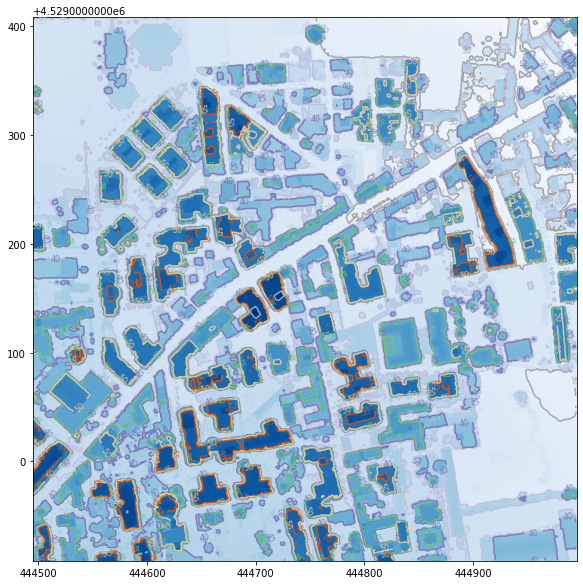

In [29]:
raster_data = rio.open(dsm)

fig, ax = plt.subplots(figsize=(10, 10))
show(
    source=raster_data,
    cmap='tab20c_r',
    contour=True,
    ax=ax,
    transform=raster_data.transform
)
show(
    source=raster_data,
    cmap='Blues',
    ax=ax,
    transform=raster_data.transform
)

In [74]:
map = folium.Map(
    location=[area_extent_centroid[1][0], area_extent_centroid[0][0]],
    tiles="OpenStreetMap",
    zoom_start=17,
    control_scale=True,
)
folium.GeoJson(vector.to_crs(4326).__geo_interface__, name="Buildings Footprint").add_to(map)
map

# Conclusione

.....

Hai commenti, indicazioni o soluzioni alternative in Python? Scrivi nella sezione [Discussioni](https://github.com/MaxDragonheart/PyGIS-Blog/discussions).

**Se vuoi sponsorizza il progetto andando su [Sponsor this project](https://github.com/MaxDragonheart/PyGIS-Blog) nella home di questo repository.**

Alla prossima!